## Esame 15 settembre

##### ESERCIZIO 1
Siano date due variabili aleatorie indipendenti $X$ e $Y$ che seguono una distribuzione normale dove $\mu_X$ è il valore atteso di $X$ e $\mu_Y$ il valore atteso di $Y$, e dove $\sigma_X$ è la deviazione standard di $X$ e $\sigma_Y$ la deviazione standard di $Y$.
Sia data $Z = X - Y$, rispondere alle seguenti domande:
1. $Z$ è una variabile aleatoria? Se sì, è discreta o continua? Motivare adeguatamente la risposta

**Soluzione**

$Z$ è una variabile aleatoria che segue una distribuzione uguale alla distribuzione di X e Y, dato che esse sono due continue, per forza anche Z sarà continua.

2. Calcolare il valore atteso di $Z$ esprimendolo in funzione di $\mu_X$ e $\mu_Y$, mostrando i passaggi

**Soluzione**

$E[Z] = E[X - Y] = E[X] - E[Y] = \mu_x - \mu_y $

3. Calcolare la varianza di $Z$ esprimendola in funzione di $\sigma_X$ e $\sigma_Y$, mostrando i passaggi

**Soluzione**

$ Var(Z) = Var(X - Y) = Var(X) + Var(Y) = \sigma_x^2 + \sigma_y^2$

4. La variabile aleatoria $Z$ segue una distribuzione normale? Motivare la risposta

**Soluzione**

Non si sa, però pensandola dal lato grafico è possibile, se faccio la differenza tra due distribuzioni che seguono la stessa

5. Calcolare la funzione di ripartizione $F_Z(x)$ esprimendola in funzione dei parametri citati sopra e utilizzando $\phi$

**Soluzione**

$ Var(Z) = \sigma_Z^2 = \sigma_X^2 + \sigma_Y^2$

$deviazione \  standard= \sigma_Z = \sqrt{\sigma_X^2 + \sigma_Y^2}$

$valore \ atteso = \mu_Z = \mu_X - \mu_Y$

$F_X(x) = P(X \le Z) = \phi(\frac{x - \mu_Z}{\sigma_Z}) = \phi(\frac{x - (\mu_X - \mu_Y)}{\sqrt{\sigma_X^2 + \sigma_Y^2}})$

6. Tenendo conto che $\mu_X = 2$, $\mu_Y = 1$, $\sigma_X = 1$ e $\sigma_Y = 2$, disegnare il grafico della funzione di ripartizione di $Z$

**Soluzione**

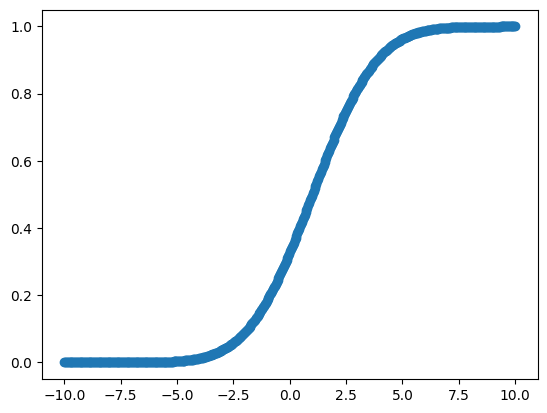

1 2.23606797749979 5.000000000000001


In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
import scipy.stats as stats

mu_x = 2
mu_y = 1
sigma_x = 1
sigma_y = 2

mu_z = mu_x - mu_y
sigma_z = np.sqrt(sigma_x**2 + sigma_y**2)
var_z = sigma_z**2


x = np.linspace(-10,10,500)
y = stats.norm.cdf((x-mu_z)/sigma_z)

plt.scatter(x,y)
plt.show()

print(mu_z, sigma_z, var_z)

## direi proprio che è una normale...

7. Calcolare la funzione di densità di probabilità $f_Z(x)$ esprimendola in funzione dei parametri sopracitati e utilizzando $\phi$

**Soluzione**

per calcolarla basta eseguire la derivata della funzione di ripartizione e quindi andando a trovare $f_Z(z) = \frac{1}{\sigma_z}*\phi(\frac{x - \mu_z}{\sigma_z}) = \frac{1}{\sqrt{\sigma_X^2 + \sigma_Y^2}}\phi(\frac{x - (\mu_X - \mu_Y)}{\sqrt{\sigma_X^2 + \sigma_Y^2}})$

8. Tenendo conto che $\mu_X = 2$, $\mu_Y = 1$, $\sigma_X = 2$ e $\sigma_Y = 2$, disegnare il grafico della funzione di densità di probabilità di $Z$

**Soluzione**

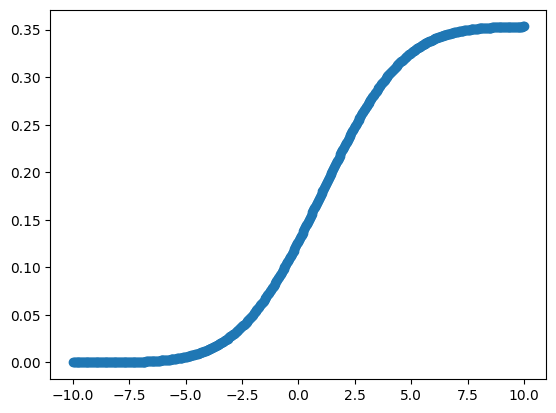

In [10]:
sigma_x = 2
sigma_z = np.sqrt(sigma_x**2 + sigma_y**2)

x = np.linspace(-10,10,500)
y = 1/(sigma_z) * stats.norm.cdf((x-mu_z)/sigma_z)

plt.scatter(x,y)
plt.show()

##### ESERCIZIO 2
Siano $Z_1, \dots, Z_n$ variabili aleatorie che descrivono un campione estratto da $Z$, distribuito come l'omonima all'esercizio precedente
1. Considerando solo in questo punto che sia noto $\mu_X$ determinare uno stimatore non distorto $U$ che stimi $\mu_Y$

**Soluzione**

2. Considerando solo in questo punto che $\sigma_X = \sigma_Y$ determinare uno stimatore non distorto $V$ che stimi $\sigma_X^2$

**Soluzione**

3. Determinare se lo stimatore $U$ è consistente in media quadratica

**Soluzione**

4. È possibile fare lo stesso ragionamento per $V$? Se no motivare la risposta, altrimenti determinare se lo stimatore è consistente in media quadratica

**Soluzione**

5. Dato $\epsilon$, determinare la probabilità che lo stimatore $U$ presenti al più un errore di $\epsilon$

**Soluzione**

##### ESERCIZIO 3
Collegatevi al sito upload.di.unimi.it, selezionate l'esame di _Statistica e analisi dei dati_ per l'appello odierno e scaricate il file `punteggi.csv`. Questo file contiene le seguenti informazioni, che descrivono una serie di incontri tra due giocatori, $X$ e $Y$, ai quali tre arbitri A, B e C hanno dato dei punteggi:
- `differenza`: è la differenza dei punteggi di $X$ è $Y$ assegnati in quell'incontro;
- `arbitro`: indica l'arbitro che ha assegnato i punti nella partita;
- `temperatura`: indica la temperatura durante l'incontro.
1. Descrivere i dati e determinarne i tipi

**Soluzione**

differenza     float64
arbitro            str
temperatura      int64
dtype: object
   differenza arbitro  temperatura
0      -3.079       C           25
1      -6.277       A           32
2      -2.524       C           19
3      -3.326       C           24
4      -4.797       A           21
arbitro
A    355
B    326
C    319
Name: count, dtype: int64


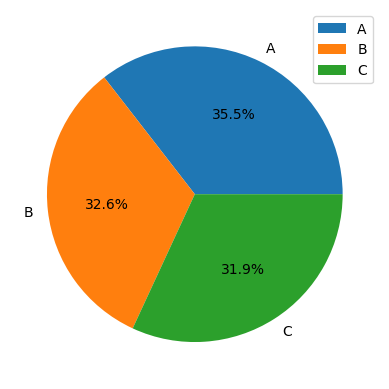

In [28]:
dati = pd.read_csv("punteggi.csv")

print(dati.dtypes)

print(dati.head())

print(dati.arbitro.value_counts())

plt.pie(dati["arbitro"].value_counts(), labels=["A","B","C"], autopct="%1.1f%%"
)
plt.legend()
plt.show()

2. Si ha il sospetto che l'arbitro A abbia un pregiudizio sul giocatore $X$, determinare un indice che consenta di confermare o confutare questa ipotesi

**Soluzione**

In [40]:
dati_arbitro_A = dati[dati["arbitro"] == "A"]

print(dati_arbitro_A["differenza"].mean())

dati_arbitro_B = dati[dati["arbitro"] == "B"]

print(dati_arbitro_B["differenza"].mean())

dati_arbitro_C = dati[dati["arbitro"] == "C"]

print(dati_arbitro_C["differenza"].mean())

## ci sta ha ragione, gli sta sul cazzo il giocatore...

-3.957281690140845
-3.0252361963190184
-3.090827586206897


3. Determinare se è presente un qualche tipo di influenza tra la temperatura e la differenza dei punteggi

**Soluzione**

-0.029917966105814903


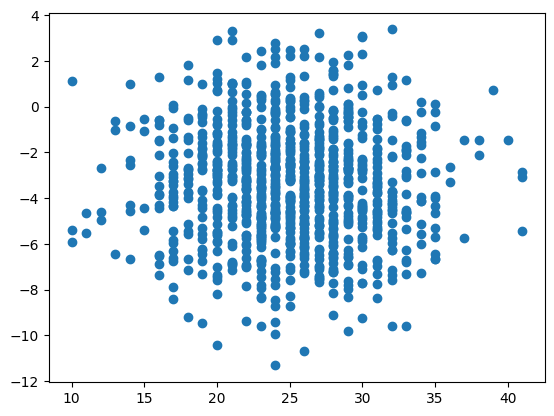

In [43]:
print(dati.temperatura.corr(dati.differenza))

plt.scatter(dati.temperatura, dati.differenza)

## non c'entra un cazzo

4. Stabilire se temperatura segue una distribuzione normale

**Soluzione**

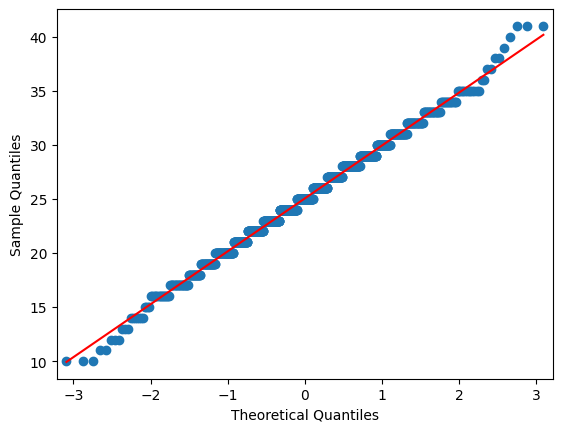

In [48]:
sm.qqplot(dati.temperatura, line="s")
plt.show()

## ci sta la segue una distribuzione abbastanza normale

5. I punteggi dati dagli arbitri sono disomogenei, trovare un indice che consenta di confermare o confutare questa ipotesi (?)


**Soluzione**

In [60]:
freq_rel = dati["arbitro"].value_counts(normalize=True)
k = len(freq_rel)
gini = 1 - np.sum(freq_rel**2)
gini_norm = gini / (1 - 1/k)
print(gini, gini_norm)

## particolarmente disomogenei... quasi il 100%

0.6659379999999999 0.9989069999999998


##### ESERCIZIO 4
Prendendo in considerazione che `differenza` sia distribuito come $Z$
1. Sapendo che $\mu_X = 5$ calcolare una stima di $\mu_Y$

**Soluzione**

In [62]:
mu_z = dati.differenza.mean()
mu_x = 5

## siccome il valore atteso di Z è quello di X meno quello di Y, allora il valore atteso di Y è: valore attezo di X meno quello di zeta

print(mu_z - mu_x)

-8.377036


2. Calcolare una stima per $\sigma_X^2$ evidenziando le proprietà dello stimatore

**Soluzione**

In [64]:
print(dati.differenza.var())

## che proprietà dovrebbe avere....

6.3302425152192185


3. Calcolare $\sqrt{\sigma_X^2 + \sigma_Y^2}$

**Soluzione**

In [67]:
## sapendo che \sigma_Z è 6.3302425152192185 allora possiamo dire che è lo stesso valore, non abbiamo altro...
## potremmo usare i valori iniziali e mu_x come 5, mu_y = 2

print(np.sqrt(25 + 4))

5.385164807134504


4. Calcolare la probabilità che si verifichi un errore al più di 0.2 nella stima di $\mu_Y$

**Soluzione**

In [76]:
## partendo dalla formula: P(|Z - \mu_Z| <= \epsilon) <= 1 siccome è una distribuzione normale N(\mu_Z, \sigma_Z^2/n) allora possiamo
## risolvere e andare a scrivere che:


## P(|X - \mu| <= epsilon) = P(-\epsilon <= X - \mu <= \epsilon) possiamo ora ricondurci alla formula base per ottenere Z ovvero Z = (X - \mu)/(\sigma / sqrt(n))
## quindi possiamo scrivere che P(-\epsilon / (\sigma / sqrt(n))<= (X - \mu) / (\sigma / sqrt(n)) <= \epsilon / (\sigma / sqrt(n))) da questo
## possiamo andare a scrivere che P(-\epsilon / (\sigma / sqrt(n))<= Z <= \epsilon / (\sigma / sqrt(n)))
## quindi che \phi(\epsilon / (\sigma / sqrt(n))) - \phi(-\epsilon / (\sigma / sqrt(n)))
## quindi che 2*\phi((\epsilon * sqrt(n)) / sigma) - 1

print(2 * stats.norm.cdf((0.2*(np.sqrt(len(dati.differenza))))/(dati.differenza.var())) - 1)

0.6822545158043773


5. Determinare se sono presenti valori nulli in `differenza`

**Soluzione**

In [71]:
print(dati.differenza.isnull().sum())

## non ci sono valori nulli...

0


6. Utilizzando le stime fatte negli esercizi precedenti per sostituire i valori nulli, calcolare le seguenti probabilità
    1. Che X vinca contro Y
    2. Che X batta Y almeno 3 volte su 10
    3. Che X batta Y almeno 3 volte sapendo che X ne ha vinte almeno 2
    4. Che X vinca dopo almeno 3 sconfitte
    5. Che X vinca dopo almeno 3 sconfitte sapendo che Y ha vinto la prima


**Soluzione**

In [79]:
print("Vince X contro Y: ", (len(dati[dati["differenza"] > 0]) / len(dati.differenza)) * 100, "% delle volte")

print("P(X >= 0.3) = 1 - P(X <= 0.3) =", )

Vince X contro Y:  8.9 % delle volte
